In [ ]:
import sys
sys.path.append("..")
from torch.utils.data import DataLoader
import torch
from data.dataset import CarRacingDataset
from modules.vae import VAE, vae_loss

dataset = CarRacingDataset(data_dir='../data/saved_rollouts')
dataloader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=2)
device=  torch.device("cuda" if torch.cuda.is_available() else "cpu")


import torch.optim as optim
from tqdm import tqdm
model = VAE(latent_dim=32).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

### Overfit single batch

In [ ]:
single_batch = next(iter(dataloader)).to(device)
def overfit_single_batch(model, batch, optimizer, epochs=500):
    model.train()
    for epoch in tqdm(range(epochs)):
        recon_x, mu, logvar = model(batch)
        loss = vae_loss(recon_x, batch, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item()}")
    return model
overfit_model = overfit_single_batch(model, single_batch, optimizer, epochs=500)
torch.save(overfit_model.state_dict(), 'vae_overfit.pt')

### Train

In [ ]:
import torch
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
import os
import torch.optimizer as optim

def train_vae(model, dataloader, optimizer, device, epochs=10, log_dir="runs/vae"):
    writer = SummaryWriter(log_dir)
    model = model.to(device)
    model.train()

    global_step = 0

    for epoch in range(epochs):
        total_loss = 0
        total_recon_loss = 0
        total_kl_loss = 0

        progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")

        for batch in progress_bar:
            batch = batch.to(device)

            recon_x, mu, log_var = model(batch)

            # Reconstruction and KL loss
            recon_loss = torch.nn.functional.mse_loss(recon_x, batch, reduction='sum')
            kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
            loss = recon_loss + kl_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_recon_loss += recon_loss.item()
            total_kl_loss += kl_loss.item()

            # Log per step
            writer.add_scalar("Loss/Total", loss.item(), global_step)
            writer.add_scalar("Loss/Reconstruction", recon_loss.item(), global_step)
            writer.add_scalar("Loss/KL", kl_loss.item(), global_step)
            global_step += 1

        avg_loss = total_loss / len(dataloader.dataset)
        avg_recon = total_recon_loss / len(dataloader.dataset)
        avg_kl = total_kl_loss / len(dataloader.dataset)

        tqdm.write(f"Epoch {epoch+1}: Total Loss={avg_loss:.2f}, Recon Loss={avg_recon:.2f}, KL Loss={avg_kl:.2f}")

        # Save checkpoint
        os.makedirs("checkpoints", exist_ok=True)
        torch.save(model.state_dict(), f"checkpoints/vae_epoch_{epoch+1}.pth")

    writer.close()

# Visualize trained VAE outputs

### Sample from latent space

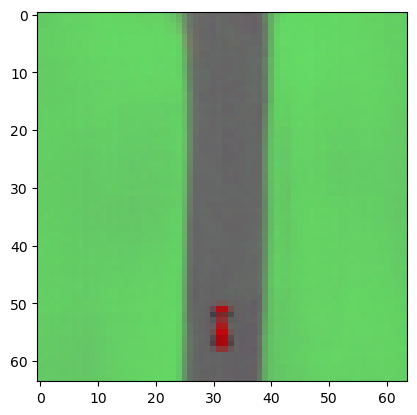

In [79]:
# Sample from latent space
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    z = torch.randn(1, 32).to('cpu')
    gen = model.decoder(z)
    plt.imshow(gen[0].permute(1, 2, 0).cpu().numpy())


### Reconstruction

Reconstruction shape: torch.Size([1, 3, 64, 64])


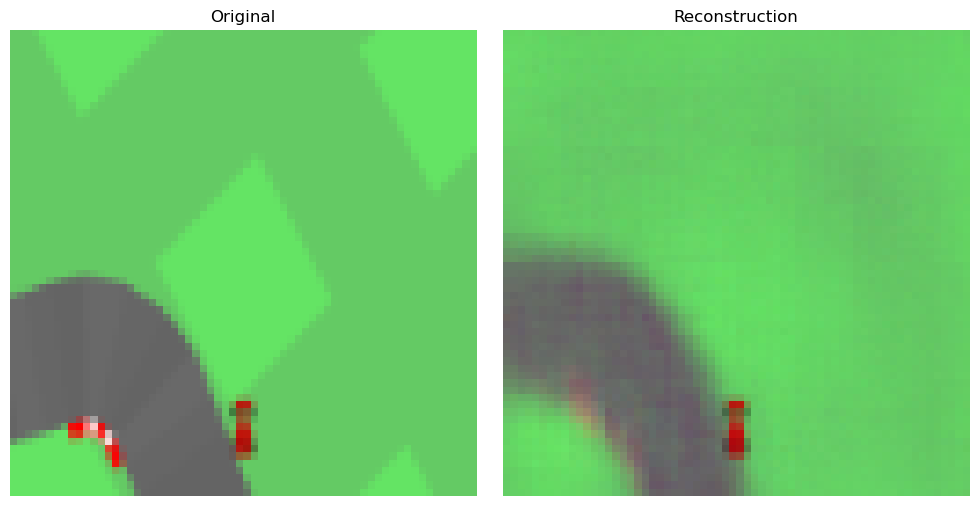

In [77]:
import numpy as np
data_npz = np.load(f'../data/data_roll100_maxts1k/rollout_00000.npz')
obs = data_npz['observations'][np.random.randint(0, len(data_npz['observations']))]
# plt.imshow(obs)
obs.shape
# model expects input of [N, 3, 64, 64]
obs = torch.tensor(obs).to('cpu').float().permute(2, 0, 1).unsqueeze(0) / 255.0

# load model
model = VAE(latent_dim=32).to('cpu')
model.load_state_dict(torch.load('../train/vae_l32_epoch1.pt', map_location='cpu'))
model.eval()

# forward pass
with torch.no_grad():
    recon_x, mu, log_var = model(obs)
    print(f"Reconstruction shape: {recon_x.shape}")

recon_x_image = recon_x.squeeze(0).permute(1,2,0).detach().numpy()

# plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
original_image = obs.squeeze(0).permute(1, 2, 0).numpy()
ax1.imshow(original_image)
ax1.set_title('Original')
ax1.axis('off')
# Reconstruction
ax2.imshow(recon_x_image)
ax2.set_title('Reconstruction')
ax2.axis('off')
plt.tight_layout()
plt.show()
